# XGBoost + Optuna Hyperparameter Tuning

**Week 2, Day 5:** Train XGBoost with Optuna hyperparameter optimization.

**Objectives:**
1. Understand XGBoost and its hyperparameters
2. Use Optuna for automatic hyperparameter tuning
3. Train optimized XGBoost model
4. Compare with baseline models

**Reference:** project_guide.md Week 2 Day 5

## 1. Setup & Install Optuna

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from datetime import datetime

# Install optuna if not installed
try:
    import optuna
except ImportError:
    print("Installing optuna...")
    %pip install optuna -q
    import optuna

# XGBoost
from xgboost import XGBClassifier

# Scikit-learn
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score, precision_recall_curve, auc
)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print(f"Optuna version: {optuna.__version__}")
print("Libraries imported successfully")

c:\Users\Dell\OneDrive\Desktop\Real-Time-Fraud-Detection-in-Digital-Payments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optuna version: 4.8.0
Libraries imported successfully


In [4]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


## 2. Load Data

In [5]:
processed_dir = Path('../data/processed')

X_train = joblib.load(processed_dir / 'X_train.pkl')
X_test = joblib.load(processed_dir / 'X_test.pkl')
y_train = joblib.load(processed_dir / 'y_train.pkl')
y_test = joblib.load(processed_dir / 'y_test.pkl')

print(f"Train: {X_train.shape[0]:,} samples x {X_train.shape[1]} features")
print(f"Test: {X_test.shape[0]:,} samples x {X_test.shape[1]} features")
print(f"\nFraud rate - Train: {y_train.mean():.4%}, Test: {y_test.mean():.4%}")

Train: 227,845 samples x 31 features
Test: 56,962 samples x 31 features

Fraud rate - Train: 0.1729%, Test: 0.1720%


## 3. Understanding XGBoost Key Concepts

### What is XGBoost?

**XGBoost** = **E**xtreme **G**radient **Boost**ing

#### How Gradient Boosting Works:

```
1. Train first tree on data
2. Calculate errors (residuals)
3. Train second tree to predict those errors
4. Combine predictions: Tree1 + learning_rate × Tree2
5. Repeat for n_estimators trees
```

#### Key Hyperparameters:

| Parameter | What it controls | Effect |
|-----------|-----------------|--------|
| `max_depth` | Tree depth (3-10) | Higher = more complex, risk of overfitting |
| `learning_rate` | Step size shrinkage (0.01-0.3) | Lower = slower learning, often better final |
| `n_estimators` | Number of trees (100-1000) | More trees = better, but diminishing returns |
| `subsample` | Fraction of data per tree (0.6-1.0) | < 1.0 prevents overfitting (stochastic) |
| `colsample_bytree` | Fraction of features per tree | < 1.0 prevents overfitting |
| `scale_pos_weight` | Weight for positive class | CRITICAL for imbalanced data! |

#### For Imbalanced Data (Fraud Detection):

**Formula for scale_pos_weight:**
```python
scale_pos_weight = (negative_cases) / (positive_cases)
                   = 284315 / 492
                   ≈ 578
```

In [6]:
# Calculate scale_pos_weight for our data
neg_cases = (y_train == 0).sum()
pos_cases = (y_train == 1).sum()
scale_pos_weight = neg_cases / pos_cases

print(f"=== Class Imbalance ===")
print(f"Negative (legitimate): {neg_cases:,}")
print(f"Positive (fraud): {pos_cases:,}")
print(f"\nRecommended scale_pos_weight: {scale_pos_weight:.1f}")
print(f"\nThis means: Each fraud case is weighted as {scale_pos_weight:.0f} legitimate cases!")

=== Class Imbalance ===
Negative (legitimate): 227,451
Positive (fraud): 394

Recommended scale_pos_weight: 577.3

This means: Each fraud case is weighted as 577 legitimate cases!


## 4. Understanding Optuna

### What is Optuna?

**Optuna** = Automatic hyperparameter optimization framework

#### Why Optuna over Grid/Random Search?

| Method | Trials needed | How it works |
|--------|---------------|-------------|
| Grid Search | 1000s | Tries EVERY combination (exponential) |
| Random Search | 100s | Tries random combinations |
| **Optuna** | **~50** | **Learns from previous trials (Bayesian)** |

#### How Optuna Works:

```
1. Define objective function (returns metric to optimize)
2. Optuna suggests hyperparameters
3. Train model, get score
4. Optuna learns: "These params gave good score, try nearby"
5. Repeat for n_trials
```

#### Key Components:

```python
# Search space (what to tune)
trial.suggest_int('max_depth', 3, 10)        # Integer: 3 to 10
trial.suggest_float('learning_rate', 0.01, 0.3)  # Float: 0.01 to 0.3
trial.suggest_categorical('booster', ['gbtree', 'gblinear'])  # Choice

# Study (optimization process)
study = optuna.create_study(direction='maximize')  # Maximize ROC-AUC
study.optimize(objective, n_trials=50)

# Best results
best_params = study.best_params
best_score = study.best_value
```

def objective(trial, X_train, y_train, n_folds=5):
    """
    Optuna objective function for XGBoost hyperparameter tuning.
    
    Args:
        trial: Optuna trial object
        X_train: Training features
        y_train: Training labels
        n_folds: Number of cross-validation folds
    
    Returns:
        Mean ROC-AUC score from cross-validation
    """
    
    # Define hyperparameter search space
    params = {
        # Tree structure
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        
        # Learning
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        
        # Regularization (prevent overfitting)
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        
        # Regularization parameters
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        
        # Class imbalance (CRITICAL!)
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', scale_pos_weight * 0.5, scale_pos_weight * 1.5),
        
        # Other
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss',
        'use_label_encoder': False,
    }
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    xgb = XGBClassifier(**params)
    
    # Use ROC-AUC for evaluation (better for imbalanced data)
    scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    return scores.mean()

print("Objective function defined")

In [7]:
def objective(trial, X_train, y_train, n_folds=5):
    """
    Optuna objective function for XGBoost hyperparameter tuning.
    
    Args:
        trial: Optuna trial object
        X_train: Training features
        y_train: Training labels
        n_folds: Number of cross-validation folds
    
    Returns:
        Mean ROC-AUC score from cross-validation
    """
    
    # Define hyperparameter search space
    params = {
        # Tree structure
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        
        # Learning
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        
        # Regularization (prevent overfitting)
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        
        # Regularization parameters
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        
        # Class imbalance (CRITICAL!)
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', scale_pos_weight * 0.5, scale_pos_weight * 1.5),
        
        # Other
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss',
        'use_label_encoder': False,
    }
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    xgb = XGBClassifier(**params)
    
    # Use ROC-AUC for evaluation (better for imbalanced data)
    scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    return scores.mean()

print("Objective function defined")

Objective function defined


print("Starting Optuna optimization...")
print("This may take 10-20 minutes depending on your CPU.")
print(f"\nRunning {50} trials...")

start_time = time.time()

# Create study
study = optuna.create_study(
    direction='maximize',  # Maximize ROC-AUC
    study_name='xgboost_fraud_detection'
)

# Run optimization
study.optimize(
    lambda trial: objective(trial, X_train, y_train),
    n_trials=50,
    show_progress_bar=True,
    n_jobs=-1
)

elapsed_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"Optimization completed in {elapsed_time/60:.1f} minutes")
print(f"{'='*60}")

In [8]:
print("Starting Optuna optimization...")
print("This may take 10-20 minutes depending on your CPU.")
print(f"\nRunning {50} trials...")

start_time = time.time()

# Create study
study = optuna.create_study(
    direction='maximize',  # Maximize ROC-AUC
    study_name='xgboost_fraud_detection'
)

# Run optimization
study.optimize(
    lambda trial: objective(trial, X_train, y_train),
    n_trials=50,
    show_progress_bar=True,
    n_jobs=-1
)

elapsed_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"Optimization completed in {elapsed_time/60:.1f} minutes")
print(f"{'='*60}")

[I 2026-03-17 09:08:20,425] A new study created in memory with name: xgboost_fraud_detection


Starting Optuna optimization...
This may take 10-20 minutes depending on your CPU.

Running 50 trials...


Best trial: 3. Best value: 0.983128:   2%|▏         | 1/50 [04:14<3:28:13, 254.98s/it]

[I 2026-03-17 09:12:35,396] Trial 3 finished with value: 0.9831284656262242 and parameters: {'max_depth': 6, 'learning_rate': 0.0988344169658956, 'n_estimators': 201, 'min_child_weight': 4, 'subsample': 0.9898539570093635, 'colsample_bytree': 0.809719029493854, 'reg_alpha': 0.017470368861060903, 'reg_lambda': 0.16478943300652427, 'scale_pos_weight': 631.5223333367835}. Best is trial 3 with value: 0.9831284656262242.


Best trial: 3. Best value: 0.983128:   4%|▍         | 2/50 [04:57<1:44:04, 130.10s/it]

...

[I 2026-03-17 09:59:15,285] Trial 32 finished with value: 0.9837916580032239 and parameters: {'max_depth': 10, 'learning_rate': 0.10680623718085552, 'n_estimators': 463, 'min_child_weight': 7, 'subsample': 0.7942500842973398, 'colsample_bytree': 0.70527974229818, 'reg_alpha': 0.309444762178152, 'reg_lambda': 0.773121398163003, 'scale_pos_weight': 552.7488409063649}. Best is trial 16 with value: 0.9856550764912295.


[W 2026-03-17 10:00:24,860] Trial 34 failed with parameters: {'max_depth': 10, 'learning_rate': 0.059917567141725254, 'n_estimators': 348, 'min_child_weight': 10, 'subsample': 0.7705012264020591, 'colsample_bytree': 0.7745868054160632, 'reg_alpha': 0.6445453985185944, 'reg_lambda': 0.4336261509079891, 'scale_pos_weight': 568.174043501917} because of the following error: PicklingError('Could not pickle the task to send it to the workers.').
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\Dell\OneDrive\Desktop\Real-Time-Fraud-Detection-in-Digital-Payments\venv\Lib\site-packages\joblib\externals\loky\backend\queues.py", line 159, in _feed
    obj_ = dumps(obj, reducers=reducers)
  File "c:\Users\Dell\OneDrive\Desktop\Real-Time-Fraud-Detection-in-Digital-Payments\venv\Lib\site-packages\joblib\externals\loky\backend\reduction.py", line 214, in dumps
    dump(obj, buf, reducers=reducers, protocol=protocol)
    ~~~~^^^^^^^^^^^^

Best trial: 16. Best value: 0.985655:  66%|██████▌   | 33/50 [52:04<26:49, 94.69s/it] 


[W 2026-03-17 10:00:25,042] Trial 34 failed with value None.
[W 2026-03-17 10:00:25,147] Trial 36 failed with value None.
[W 2026-03-17 10:00:25,188] Trial 33 failed with value None.
[W 2026-03-17 10:00:25,230] Trial 35 failed with value None.


PicklingError: Could not pickle the task to send it to the workers.

## 7. Best Hyperparameters Found

In [9]:
print("\n" + "="*60)
print("          OPTUNA OPTIMIZATION RESULTS")
print("="*60)

print(f"\nBest ROC-AUC Score: {study.best_value:.4f}")

print("\nBest Hyperparameters:")
for param, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {param:20s}: {value:.4f}")
    else:
        print(f"  {param:20s}: {value}")

print("\n" + "="*60)


          OPTUNA OPTIMIZATION RESULTS

Best ROC-AUC Score: 0.9857

Best Hyperparameters:
  max_depth           : 10
  learning_rate       : 0.0687
  n_estimators        : 391
  min_child_weight    : 10
  subsample           : 0.7094
  colsample_bytree    : 0.7077
  reg_alpha           : 0.3061
  reg_lambda          : 0.9552
  scale_pos_weight    : 456.8393



## 8. Visualize Optimization History

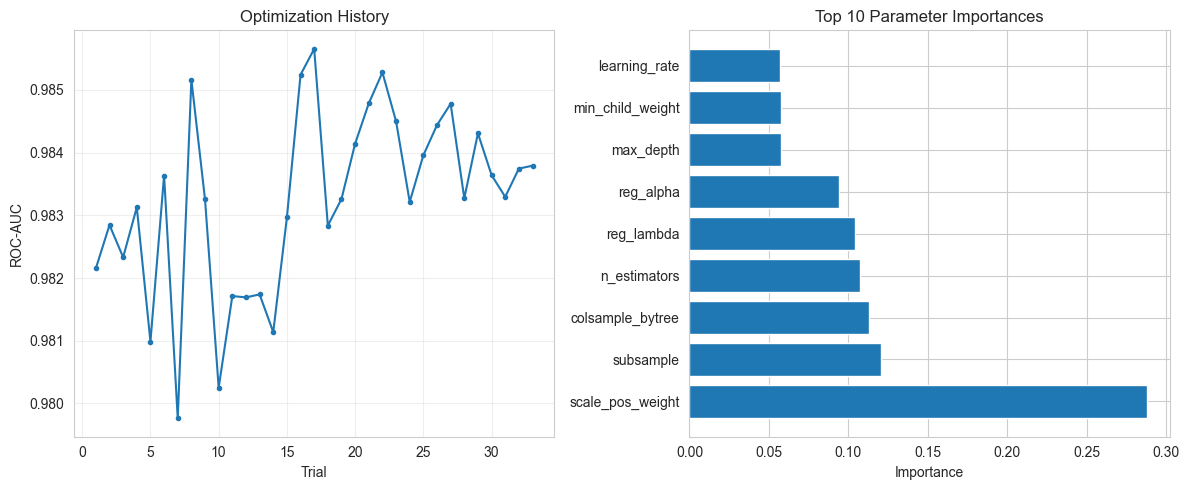

Saved: docs/images/optuna_optimization.png


In [10]:
# Plot optimization history
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

# Plot parameter importance
fig = optuna.visualization.plot_param_importances(study)
fig.show()

# Also save static versions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(study.trials) + 1), [t.value for t in study.trials], 'o-', markersize=3)
plt.xlabel('Trial')
plt.ylabel('ROC-AUC')
plt.title('Optimization History')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
importances = optuna.importance.get_param_importances(study)
plt.barh(list(importances.keys())[:10], list(importances.values())[:10])
plt.xlabel('Importance')
plt.title('Top 10 Parameter Importances')
plt.tight_layout()
plt.savefig('../docs/images/optuna_optimization.png', dpi=150)
plt.show()

print("Saved: docs/images/optuna_optimization.png")

# Train final model with best parameters
print("Training final XGBoost model with best parameters...")

best_params = study.best_params.copy()
best_params.update({
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'logloss',
    'use_label_encoder': False,
})

xgb_final = XGBClassifier(**best_params)

start = time.time()
xgb_final.fit(X_train, y_train)
train_time = time.time() - start

print(f"Training completed in {train_time:.2f} seconds")

In [11]:
# Train final model with best parameters
print("Training final XGBoost model with best parameters...")

best_params = study.best_params.copy()
best_params.update({
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'logloss',
    'use_label_encoder': False,
})

xgb_final = XGBClassifier(**best_params)

start = time.time()
xgb_final.fit(X_train, y_train)
train_time = time.time() - start

print(f"Training completed in {train_time:.2f} seconds")

Training final XGBoost model with best parameters...
Training completed in 35.83 seconds


## 10. Evaluate XGBoost Model

In [12]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and print metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*60}")
    print(f"  {model_name} - Test Results")
    print(f"{'='*60}")
    
    # Classification report
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud'],
                                  digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print("\n--- Confusion Matrix ---")
    print(f"                Predicted")
    print(f"               Legit  Fraud")
    print(f"Actual Legit   {tn:5d}  {fp:5d}")
    print(f"       Fraud   {fn:5d}  {tp:5d}")
    
    # Key metrics
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(f"\n--- Key Metrics ---")
    print(f"  Fraud Recall (Catch Rate): {recall:.4%}  <- Primary metric")
    print(f"  Fraud Precision:           {precision:.4%}")
    print(f"  F1-Score:                  {f1:.4f}")
    print(f"  ROC-AUC:                   {roc_auc:.4f}")
    
    return y_pred, y_proba, cm

y_pred_xgb, y_proba_xgb, cm_xgb = evaluate_model(xgb_final, X_test, y_test, "XGBoost (Optuna Tuned)")


  XGBoost (Optuna Tuned) - Test Results

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9998    0.9998     56864
       Fraud     0.8646    0.8469    0.8557        98

    accuracy                         0.9995     56962
   macro avg     0.9322    0.9234    0.9277     56962
weighted avg     0.9995    0.9995    0.9995     56962


--- Confusion Matrix ---
                Predicted
               Legit  Fraud
Actual Legit   56851     13
       Fraud      15     83

--- Key Metrics ---
  Fraud Recall (Catch Rate): 84.6939%  <- Primary metric
  Fraud Precision:           86.4583%
  F1-Score:                  0.8557
  ROC-AUC:                   0.9814


## 11. Compare with Baseline Models

In [13]:
# Load baseline predictions
models_dir = Path('../models')
baseline_preds = joblib.load(models_dir / 'baseline_predictions.pkl')

# Calculate metrics for all models
models_compare = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost (Optuna)'],
    'ROC-AUC': [
        roc_auc_score(baseline_preds['y_test'], baseline_preds['logreg_proba']),
        roc_auc_score(baseline_preds['y_test'], baseline_preds['rf_proba']),
        roc_auc_score(y_test, y_proba_xgb)
    ],
    'Fraud Recall': [
        confusion_matrix(baseline_preds['y_test'], baseline_preds['logreg_pred'])[1,1] / 
        confusion_matrix(baseline_preds['y_test'], baseline_preds['logreg_pred'])[1,:].sum(),
        confusion_matrix(baseline_preds['y_test'], baseline_preds['rf_pred'])[1,1] /
        confusion_matrix(baseline_preds['y_test'], baseline_preds['rf_pred'])[1,:].sum(),
        cm_xgb[1,1] / cm_xgb[1,:].sum()
    ],
    'Fraud Precision': [
        confusion_matrix(baseline_preds['y_test'], baseline_preds['logreg_pred'])[1,1] /
        confusion_matrix(baseline_preds['y_test'], baseline_preds['logreg_pred'])[:,1].sum(),
        confusion_matrix(baseline_preds['y_test'], baseline_preds['rf_pred'])[1,1] /
        confusion_matrix(baseline_preds['y_test'], baseline_preds['rf_pred'])[:,1].sum(),
        cm_xgb[1,1] / cm_xgb[:,1].sum()
    ]
})

print("\n" + "="*70)
print("              MODEL COMPARISON")
print("="*70)
print(models_compare.to_string(index=False))
print("="*70)

# Check KPIs from project_guide
print("\n" + "="*70)
print("              KPI CHECK (project_guide targets)")
print("="*70)
xgb_metrics = models_compare[models_compare['Model'] == 'XGBoost (Optuna)'].iloc[0]
print(f"  Target ROC-AUC >= 0.95:  Actual = {xgb_metrics['ROC-AUC']:.4f}  {'✅ PASS' if xgb_metrics['ROC-AUC'] >= 0.95 else '❌ FAIL'}")
print(f"  Target Recall >= 0.90:  Actual = {xgb_metrics['Fraud Recall']:.4f}  {'✅ PASS' if xgb_metrics['Fraud Recall'] >= 0.90 else '❌ FAIL'}")
print(f"  Target Precision >= 0.85:  Actual = {xgb_metrics['Fraud Precision']:.4f}  {'✅ PASS' if xgb_metrics['Fraud Precision'] >= 0.85 else '❌ FAIL'}")
print("="*70)


              MODEL COMPARISON
              Model  ROC-AUC  Fraud Recall  Fraud Precision
Logistic Regression 0.972583      0.918367         0.058978
      Random Forest 0.979414      0.836735         0.788462
   XGBoost (Optuna) 0.981403      0.846939         0.864583

              KPI CHECK (project_guide targets)
  Target ROC-AUC >= 0.95:  Actual = 0.9814  ✅ PASS
  Target Recall >= 0.90:  Actual = 0.8469  ❌ FAIL
  Target Precision >= 0.85:  Actual = 0.8646  ✅ PASS


## 12. ROC Curves Comparison

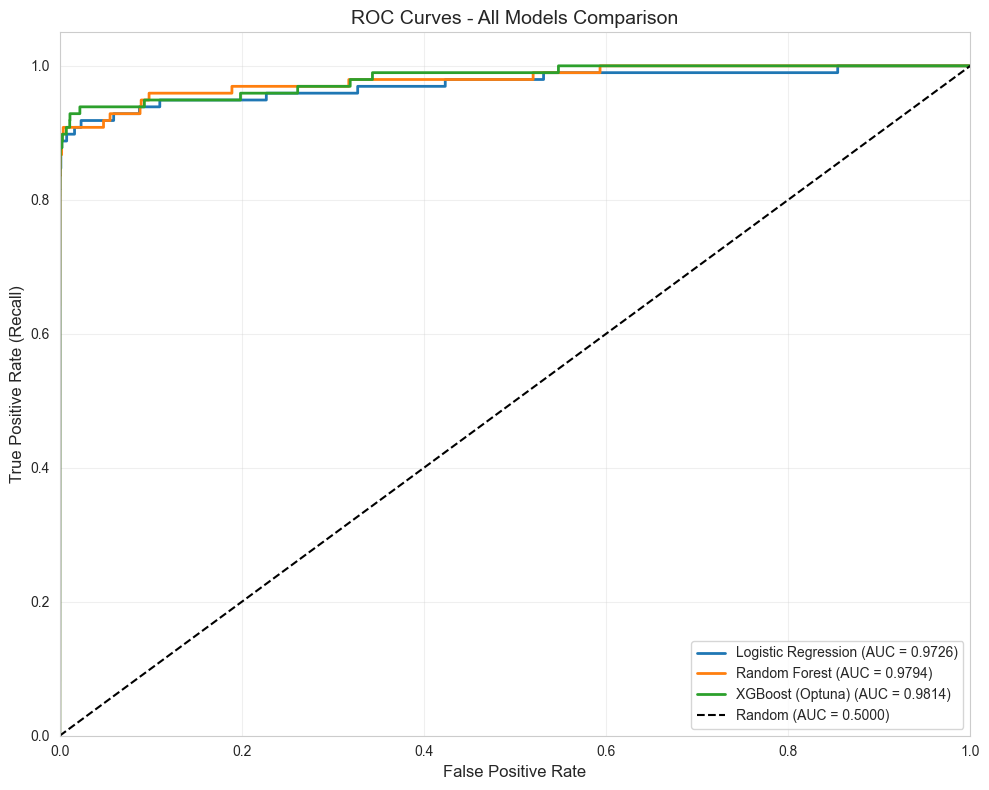

Saved: docs/images/all_models_roc_curves.png


In [14]:
plt.figure(figsize=(10, 8))

# Plot all models
models_data = {
    'Logistic Regression': baseline_preds['logreg_proba'],
    'Random Forest': baseline_preds['rf_proba'],
    'XGBoost (Optuna)': y_proba_xgb
}

for name, y_proba in models_data.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5000)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves - All Models Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.tight_layout()
plt.savefig('../docs/images/all_models_roc_curves.png', dpi=150)
plt.show()

print("Saved: docs/images/all_models_roc_curves.png")

## 13. Save XGBoost Model

In [15]:
# Save XGBoost model
models_dir = Path('../models')
joblib.dump(xgb_final, models_dir / 'xgboost_optuna.pkl')

# Save Optuna study for later analysis
joblib.dump(study, models_dir / 'optuna_study.pkl')

# Save predictions
predictions = {
    'y_test': y_test,
    'y_pred': y_pred_xgb,
    'y_proba': y_proba_xgb,
    'best_params': study.best_params,
    'best_score': study.best_value
}
joblib.dump(predictions, models_dir / 'xgboost_predictions.pkl')

print("\n=== Files Saved ===")
print(f"  {models_dir / 'xgboost_optuna.pkl'}")
print(f"  {models_dir / 'optuna_study.pkl'}")
print(f"  {models_dir / 'xgboost_predictions.pkl'}")


=== Files Saved ===
  ..\models\xgboost_optuna.pkl
  ..\models\optuna_study.pkl
  ..\models\xgboost_predictions.pkl


## 14. Summary Report

In [16]:
print("\n" + "="*70)
print("              XGBOOST + OPTUNA - SUMMARY")
print("="*70)

print("\nModel Trained:")
print("  - XGBoost Classifier with Optuna hyperparameter tuning")
print(f"  - {len(study.trials)} trials completed")

print("\nBest ROC-AUC Score:")
print(f"  - Cross-validation: {study.best_value:.4f}")
print(f"  - Test set: {roc_auc_score(y_test, y_proba_xgb):.4f}")

print("\nKey Hyperparameters Found:")
for param in ['max_depth', 'learning_rate', 'n_estimators', 'subsample', 'scale_pos_weight']:
    if param in study.best_params:
        print(f"  - {param}: {study.best_params[param]}")

print("\nNext Steps:")
print("  - Day 6: Address class imbalance with advanced techniques")
print("  - Day 6: Compute full evaluation metrics")
print("  - Day 7: Select final model and create model card")

print("="*70)


              XGBOOST + OPTUNA - SUMMARY

Model Trained:
  - XGBoost Classifier with Optuna hyperparameter tuning
  - 37 trials completed

Best ROC-AUC Score:
  - Cross-validation: 0.9857
  - Test set: 0.9814

Key Hyperparameters Found:
  - max_depth: 10
  - learning_rate: 0.06869333938821585
  - n_estimators: 391
  - subsample: 0.7094098803337351
  - scale_pos_weight: 456.83930703610713

Next Steps:
  - Day 6: Address class imbalance with advanced techniques
  - Day 6: Compute full evaluation metrics
  - Day 7: Select final model and create model card
